# Path Tracing Notebook
Implementation of Light Transport Algorithms

********************************************************************************************

In [1]:
import taichi as ti
ti.init(arch=ti.cpu, debug=True, random_seed=68739)

[Taichi] version 1.6.0, llvm 15.0.7, commit f1c6fbbd, osx, python 3.11.4
[Taichi] Starting on arch=arm64


[I 03/07/25 03:30:29.244 5341755] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


In [2]:
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from taichi.math import vec3, cross, normalize, dot

In [3]:
cvpt_example = "../scenes/cvpt.pbrt"


file_path = cvpt_example

In [4]:
from primitives.primitives import Primitive

n_p = 1024
PS = ti.root.dense(ti.i, n_p)
primitives = Primitive.field()
PS.place(primitives)

<ti.SNode of type dense>

In [5]:
from pbrt.transformations import parse_transform
from pbrt.material_parser import parse_materials
from pbrt.shape_parser import extract_all_shapes, parse_shapes
from pbrt.parser import pbrt_to_dict

# Parse the scene
scene_dict = pbrt_to_dict(file_path)

# Get the Transform Matrix
global_transform = parse_transform(scene_dict["Transform"])

# Extract the shapes
shapes_list = extract_all_shapes(file_path)

# Parse the materials
materials = scene_dict.get("MakeNamedMaterial", [])
# parsed_materials = parse_materials(materials)

# Extract Primitives
n_primitives, light_count = parse_shapes(shapes_list, materials, primitives, global_transform)

In [6]:
n_primitives, light_count

(14, 2)

In [7]:
primitives[11].material.uroughness

0.0

In [8]:
from base.lights import DiffuseAreaLight

# Create a Taichi field for light sources
n_lights = light_count
LS = ti.root.dense(ti.i, n_lights)
lights = DiffuseAreaLight.field()
LS.place(lights)

<ti.SNode of type dense>

In [9]:
@ti.kernel
def populate_shapes():

    for i in range(n_primitives):

        # primitives[i].bsdf.diffuse.type = 0
        # primitives[i].bsdf.transmit.type = 1
        # primitives[i].bsdf.dielectric.type = 2
        # primitives[i].bsdf.conductor.type = 3

        material = primitives[i].material

        if material.material_type==0:
            # Diffuse material
            primitives[i].bsdf.add_diffuse(material.reflectance)
        elif material.material_type==1:
            # Diffuse-Transmission material
            primitives[i].bsdf.add_transmission(material.reflectance, material.transmittance)
        elif material.material_type==2:
            # Dielectric material
            primitives[i].bsdf.add_dielectric(material.eta[0], material.reflectance, material.uroughness, material.vroughness)
        elif material.material_type==3:
            # Conductor material
            print(material.eta)
            primitives[i].bsdf.add_conductor(material.eta, material.k, material.uroughness, material.vroughness)

        if primitives[i].is_light == 1:
            print(i, primitives[i].material.emission)
            light_idx = primitives[i].light_idx
            lights[light_idx].shape_idx = i  # Link the light to the primitive
            lights[light_idx].two_sided = 0  # Assuming lights are one-sided
            lights[light_idx].Le = primitives[i].material.emission
            light_idx += 1

populate_shapes()

12 [50.000000, 50.000000, 50.000000]
13 [50.000000, 50.000000, 50.000000]


In [10]:
lights.to_numpy()

{'shape_idx': array([12, 13], dtype=int32),
 'Le': array([[50., 50., 50.],
        [50., 50., 50.]], dtype=float32),
 'two_sided': array([0, 0], dtype=int32)}

In [11]:
from primitives.aabb import AABB, BVHPrimitive

# Enclose all the primitives in their individual axis-aligned bounding boxes (AABB)
BS = ti.root.dense(ti.i, n_primitives)
bvh_primitives = BVHPrimitive.field()
BS.place(bvh_primitives)

scene_min = ti.Vector.field(3, dtype=ti.f32, shape=())  # Global min bounds
scene_max = ti.Vector.field(3, dtype=ti.f32, shape=())  # Global max bounds

@ti.kernel
def init_bounded_boxes():
    # Initialize scene bounding box with extreme values
    scene_min[None] = vec3(1e10, 1e10, 1e10)
    scene_max[None] = vec3(-1e10, -1e10, -1e10)

    for i in ti.ndrange(n_primitives):
        bvh_primitives[i].prim = primitives[i]
        bvh_primitives[i].prim_num = i

        # Get primitive bounds
        min_p, max_p = primitives[i].get_bounds()
        centroid = (min_p + max_p) * 0.5
        bvh_primitives[i].bounds = AABB(min_point=min_p, max_point=max_p, centroid=centroid)

        # Update scene-wide bounding box
        for j in range(3):  # Loop over x, y, z components
            scene_min[None][j] = min(scene_min[None][j], min_p[j])
            scene_max[None][j] = max(scene_max[None][j], max_p[j])


init_bounded_boxes()

bvh_primitives.shape[0], n_primitives

(14, 14)

In [12]:
OPS = ti.root.dense(ti.i, n_primitives)
ordered_prims = Primitive.field()
OPS.place(ordered_prims)

<ti.SNode of type dense>

In [13]:
from accelerators.bvh import BVHNode, BucketInfo

node_idx = 0

BVS = ti.root.dense(ti.i, 3 * n_primitives)
nodes = BVHNode.field()
BVS.place(nodes)


<ti.SNode of type dense>

In [14]:
nodes.shape[0]

42

In [15]:
total_nodes = ti.field(ti.i32, shape=())
split_method = ti.field(ti.i32, shape=())
start = ti.field(ti.i32, shape=())
end = ti.field(ti.i32, shape=())
ordered_prims_idx = ti.field(ti.i32, shape=())
stack_ptr = ti.field(ti.i32, shape=())
# ordered_prims_size = ti.field(ti.i32, shape=())

@ti.kernel
def init_stack():
    total_nodes[None] = 0
    split_method[None] = 0
    start[None] = 0
    end[None] = n_primitives
    ordered_prims_idx[None] = 0
    stack_ptr[None] = 0
    # ordered_prims_size[None] = 0

init_stack()

In [16]:
stack = ti.field(ti.i32, shape=(3*n_primitives, 4))
n_buckets = 12
buckets = BucketInfo.field(shape=(n_buckets))
costs = ti.field(dtype=ti.f32, shape=(n_buckets-1))

In [17]:
from accelerators.bvh import build_bvh

start_t = time.time()

build_bvh(primitives, bvh_primitives, start, end, ordered_prims, nodes, total_nodes, split_method, stack, stack_ptr, ordered_prims_idx, costs, buckets)

end_t = time.time()

In [18]:
# total_nodes = ti.field(ti.i32, shape=())
# split_method = ti.field(ti.i32, shape=())
# start = ti.field(ti.i32, shape=())
# end = ti.field(ti.i32, shape=())
# ordered_prims_idx = ti.field(ti.i32, shape=())
# stack_ptr = ti.field(ti.i32, shape=())
# max_prims_in_node = ti.field(ti.i32, shape=())
# # ordered_prims_size = ti.field(ti.i32, shape=())
#
# @ti.kernel
# def init_stack():
#     total_nodes[None] = 0
#     split_method[None] = 0
#     start[None] = 0
#     end[None] = n_primitives
#     ordered_prims_idx[None] = 0
#     stack_ptr[None] = 0
#     max_prims_in_node[None] = 4
#
# init_stack()

In [19]:
# stack = ti.field(ti.i32, shape=(3*n_primitives, 4))
# n_buckets = 12
# buckets = BucketInfo.field(shape=(n_buckets))
# costs = ti.field(dtype=ti.f32, shape=(n_buckets-1))

In [20]:
# from accelerators.hlbvh import build_hlbvh
# from accelerators.bvh import build_bvh
#
# start_t = time.time()
#
# root = ti.field(ti.i32, shape=())
#
# build_hlbvh(
#     primitives,
#     bvh_primitives,
#     ordered_prims,
#     n_primitives,       # number of actual primitives
#     nodes,
#     total_nodes,
#     ordered_prims_idx,  # you already have this
#     max_prims_in_node,
#     root
# )
#
# end_t = time.time()

In [21]:
print("Elapsed (with compilation) = %s" % (end_t - start_t))
print(f"Total Nodes: {total_nodes}")

Elapsed (with compilation) = 0.2073822021484375
Total Nodes: 23


In [22]:
from tests.test_bvh import print_bvh

print_bvh(nodes, total_nodes[None])

BVHNode 0 [Interior]: split_axis = 1 child_0 = 1 child_1 = 14 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
BVHNode 1 [Interior]: split_axis = 1 child_0 = 2 child_1 = 7 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
BVHNode 2 [Interior]: split_axis = 1 child_0 = 3 child_1 = 4 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
BVHNode 3 [Leaf]: first_prim_offset = 0 n_primitives = 1 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, -1.000000, 7.800000] )
BVHNode 4 [Interior]: split_axis = 1 child_0 = 5 child_1 = 6 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
BVHNode 5 [Leaf]: first_prim_offset = 1 n_primitives = 1 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, -1.000000, 7.800000] )
BVHNode 6 [Leaf]: first_prim_offset = 2 n_primitives = 1 bounds = (min: [-1.000000, 1.000000, 5.800000] , max: 

In [23]:
from tests.test_bvh import test_bvh
max_nodes = n_primitives
debug_stack = ti.field(dtype=ti.i32, shape=(max_nodes,))
debug_ptr = ti.field(dtype=ti.i32, shape=(1,))
error_count = ti.field(dtype=ti.i32, shape=(1,))

test_bvh(nodes, debug_stack, debug_ptr, error_count)

BVH test error count = 0


In [24]:
from accelerators.bvh import LinearBVHNode
from accelerators.bvh import flatten_bvh

# create a linear representation of the bvh tree (empty)

LBVS = ti.root.dense(ti.i, total_nodes[None])
linear_bvh = LinearBVHNode.field()
LBVS.place(linear_bvh)

stack_size = 2 * n_primitives - 1  # Maximum possible stack size
stack3 = ti.Vector.field(3, dtype=ti.i32, shape=stack_size)
stack_top_2 = ti.field(dtype=ti.i32, shape=())

start_t = time.time()
total_nodes = flatten_bvh(nodes, linear_bvh, 0, stack3, stack_top_2)
end_t = time.time()
print(f"Total flattened nodes: {total_nodes}")

Total flattened nodes: 23


In [25]:
linear_bvh[0].second_child_offset

14

In [26]:
print("Elapsed (with compilation) = %s" % (end_t - start_t))

Elapsed (with compilation) = 0.02185988426208496


In [27]:
from tests.test_linear_bvh import print_flattened_bvh

print_flattened_bvh(linear_bvh, total_nodes)

LinearBVHNode 0 [Interior]: axis = 1 second_child_offset = 14 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
LinearBVHNode 1 [Interior]: axis = 1 second_child_offset = 7 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
LinearBVHNode 2 [Interior]: axis = 1 second_child_offset = 4 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
LinearBVHNode 3 [Leaf]: primitives_offset = 0 n_primitives = 1 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, -1.000000, 7.800000] )
LinearBVHNode 4 [Interior]: axis = 1 second_child_offset = 6 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
LinearBVHNode 5 [Leaf]: primitives_offset = 1 n_primitives = 1 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, -1.000000, 7.800000] )
LinearBVHNode 6 [Leaf]: primitives_offset = 2 n_primitives = 1 bounds = (min: [-1.000000, 1.000000,

In [28]:
from tests.test_linear_bvh import test_flattened_bvh

max_nodes = n_primitives
debug_stack = ti.field(dtype=ti.i32, shape=(max_nodes,))
debug_ptr = ti.field(dtype=ti.i32, shape=(1,))
error_count = ti.field(dtype=ti.i32, shape=(1,))

test_flattened_bvh(linear_bvh, debug_stack, debug_ptr, error_count)

Flattened BVH test error count = 0


In [29]:
# Parse Camera Data

camera_data = scene_dict["Camera"][0]["properties"]
camera_data

{'fov': [19.5]}

In [30]:
scene_min[None], scene_max[None]

([-1.         -1.00000012  5.80000019], [1.         1.         7.80000019])

In [31]:
from pbrt.camera_parser import extract_camera_from_scene
from base.camera import auto_fit_camera, get_camera

eye, center, up, fov = extract_camera_from_scene(scene_dict)

# camera = auto_fit_camera(scene_min[None], scene_max[None], fov, 400, 400, 0)
camera = get_camera(eye, center, up, fov, 400, 400)

Extracted Camera Parameters: [-0.000000, -0.000000, -0.000000] [0.000000, 0.000000, 1.000000] [-0.000000, 1.000000, -0.000000] 19.500000
[-0.000000, -0.000000, -0.000000] [0.000000, 0.000000, 1.000000] [-0.000000, 1.000000, -0.000000]


In [32]:
camera

{'width': 400, 'height': 400, 'position': [-0.0, -0.0, -0.0], 'frame': {'x': [1.0, 0.0, -0.0], 'y': [-0.0, 1.0, 0.0], 'z': [-0.0, -0.0, -1.0]}, 'fov': 19.5, 'aspect_ratio': 1.0, 'lens_radius': 0.0, 'focal_distance': 1.0, 'screen_window': [-0.1718314290046692, 0.1718314290046692, -0.1718314290046692, 0.1718314290046692], 'dx_camera': [0.000859157124068588, 0.0, 0.0], 'dy_camera': [0.0, 0.000859157124068588, 0.0]}

In [33]:
scene_min[None], scene_max[None]

([-1.         -1.00000012  5.80000019], [1.         1.         7.80000019])

In [34]:
camera.frame

{'x': [1.0, 0.0, -0.0], 'y': [-0.0, 1.0, 0.0], 'z': [-0.0, -0.0, -1.0]}

In [35]:
@ti.kernel
def test_camera():
    # Generate a ray
    s, t = 0.5, 0.5  # Center of the screen
    ray_origin, ray_dir, rx_origin, rx_dir, ry_origin, ry_dir = camera.generate_ray_differential(s, t)
    print(ray_origin, ray_dir, rx_origin, rx_dir, ry_origin, ry_dir)

test_camera()

[0.000000, 0.000000, 0.000000] [0.000000, 0.000000, 1.000000] [0.000000, 0.000000, 0.000000] [0.000859, 0.000000, 1.000000] [0.000000, 0.000000, 0.000000] [0.000000, 0.000859, 1.000000]


In [51]:
from base.scene import Scene

pt = 0
mis = 1

# Instantiate a Scene object with the Camera object
scene = Scene(integrator=mis, spp=1024, max_depth=7, sample_lights=1, sample_bsdf=1)

In [52]:
ordered_prims[11].material.reflectance

[0.211 0.211 0.211]

In [53]:
# @ti.kernel
# def update_roughness():
#     # Change the material configurations of left sphere
#     ordered_prims[11].material.reflectance = vec3([0.95, 0.95, 0.95]) # white
#     # change colour to white
#     ordered_prims[11].bsdf.add_diffuse(ordered_prims[11].material.reflectance)
# update_roughness()

In [54]:
ordered_prims[11].material.reflectance

[0.94999999 0.94999999 0.94999999]

In [55]:
from base.render import render

res_x = camera.width
res_y = camera.height

# Pre‐rendered control image (H₀):
control = ti.Vector.field(3, ti.f32, shape=(res_y, res_x))


start_t = time.time()

# Call the render_scene kernel
render(scene, control, lights, camera, ordered_prims, linear_bvh)

end_t = time.time()

print("Elapsed (with compilation) = %s" % (end_t - start_t))

Elapsed (with compilation) = 47.00816893577576


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


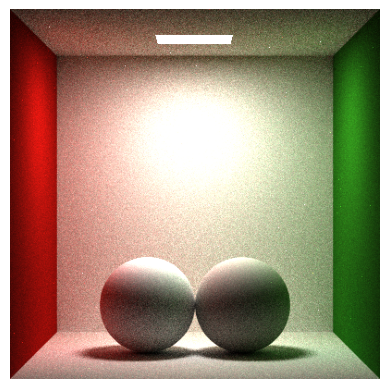

In [56]:
control_np = control.to_numpy()
# if np.isnan(image_np).any() or np.isinf(image_np).any():
#     print("Warning: NaN or Inf values detected in the image")
# image_np = np.clip(image_np, 0, 1)  # Clip values between 0 and 1
plt.imshow(control_np)
plt.axis('off')
plt.show()

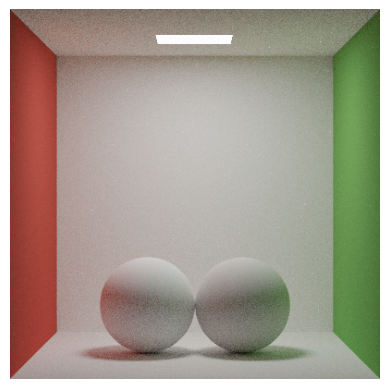

In [57]:
def tone_mapping(hdr_image, gamma=2.2):
    ldr_image = hdr_image / (1.0 + hdr_image)
    ldr_image = np.power(ldr_image, 1.0 / gamma)
    return np.clip(ldr_image, 0, 1)

ldr_control = tone_mapping(control_np)

# Display the tone-mapped image
plt.imshow(ldr_control)
plt.axis('off')
plt.show()

In [43]:
from integrators.mis_pt import trace_mis
from primitives.ray import Ray
from base.lights import UniformLightSampler
import taichi as ti
from taichi.math import vec3

# -------------------------------------------------------
# Data structures & Fields
# -------------------------------------------------------
@ti.dataclass
class CVStats:
    F_sum: ti.types.vector(3, ti.f32)
    H_sum: ti.types.vector(3, ti.f32)
    D_sum: ti.types.vector(3, ti.f32)
    FF_sum: ti.types.vector(3, ti.f32)
    HH_sum: ti.types.vector(3, ti.f32)
    FH_sum: ti.types.vector(3, ti.f32)
    count: ti.i32

# Example resolution / sample settings (adjust to your scene):
scene_spp = 64  # total SPP (split half for pass1, half for pass2)

# Global fields
stats1 = CVStats.field(shape=(res_y, res_x))   # pass1 stats
stats2 = CVStats.field(shape=(res_y, res_x))   # pass2 stats

# Pass‐1 color buffer (guides NL‐Means):
pass1_color = ti.Vector.field(3, ti.f32, shape=(res_y, res_x))

# Weighted combination factors (the final w per channel):
weights = ti.Vector.field(3, ti.f32, shape=(res_y, res_x))

# Final image (after pass2 + compositing):
image = ti.Vector.field(3, ti.f32, shape=(res_y, res_x))

# Temporary unfiltered var/cov fields:
varF_unf = ti.Vector.field(3, ti.f32, shape=(res_y, res_x))
varH_unf = ti.Vector.field(3, ti.f32, shape=(res_y, res_x))
covFH_unf = ti.Vector.field(3, ti.f32, shape=(res_y, res_x))

# Filtered var/cov fields after patch‐based NL‐Means:
varF_flt = ti.Vector.field(3, ti.f32, shape=(res_y, res_x))
varH_flt = ti.Vector.field(3, ti.f32, shape=(res_y, res_x))
covFH_flt = ti.Vector.field(3, ti.f32, shape=(res_y, res_x))


# -------------------------------------------------------
# 0) Clear stats
# -------------------------------------------------------
@ti.kernel
def clear_stats(stats: ti.template()):
    stats.F_sum.fill(0.0)
    stats.H_sum.fill(0.0)
    stats.D_sum.fill(0.0)
    stats.FF_sum.fill(0.0)
    stats.HH_sum.fill(0.0)
    stats.FH_sum.fill(0.0)
    stats.count.fill(0)


# -------------------------------------------------------
# 1) Render half the samples for pass1 or pass2
#     Now using two primitives lists:
#         primitives_old for the "old" path (control material)
#         primitives_new for the "new" path (edited material)
# -------------------------------------------------------
@ti.kernel
def render_control_variate_half(
    scene: ti.template(),
    out_image: ti.template(),   # pass1_color or pass2 image
    control_img: ti.template(),
    stats: ti.template(),
    lights: ti.template(),
    camera: ti.template(),
    primitives_old: ti.template(),
    primitives_new: ti.template(),
    bvh: ti.template(),
    start_spp: ti.i32,
    end_spp: ti.i32
):
    light_sampler = UniformLightSampler(lights.shape[0])
    height, width = camera.height, camera.width

    ti.loop_config(parallelize=4, block_dim=16)
    for j, i in ti.ndrange(height, width):
        F_accum = ti.Vector([0.0, 0.0, 0.0])
        H_accum = ti.Vector([0.0, 0.0, 0.0])
        D_accum = ti.Vector([0.0, 0.0, 0.0])
        FF_accum = ti.Vector([0.0, 0.0, 0.0])
        HH_accum = ti.Vector([0.0, 0.0, 0.0])
        FH_accum = ti.Vector([0.0, 0.0, 0.0])

        for s in range(start_spp, end_spp):
            u = (i + ti.random()) / width
            v = 1.0 - (j + ti.random()) / height

            # "Old" path (control material):
            ray_org, ray_dir = camera.generate_ray(u, v)
            ray = Ray(ray_org, ray_dir)

            H = trace_mis(ray, primitives_old, bvh, lights, light_sampler,
                          scene.sample_lights, scene.sample_bsdf, scene.max_depth)

            # "New" path (edited material):
            F = trace_mis(ray, primitives_new, bvh, lights, light_sampler,
                          scene.sample_lights, scene.sample_bsdf, scene.max_depth)

            D = F - H
            F_accum += F
            H_accum += H
            D_accum += D
            FF_accum += F * F
            HH_accum += H * H
            FH_accum += F * H

        nsamples = (end_spp - start_spp)
        stats[j, i].F_sum += F_accum
        stats[j, i].H_sum += H_accum
        stats[j, i].D_sum += D_accum
        stats[j, i].FF_sum += FF_accum
        stats[j, i].HH_sum += HH_accum
        stats[j, i].FH_sum += FH_accum
        stats[j, i].count += nsamples

        out_image[j, i] += (F_accum / float(nsamples))


# -------------------------------------------------------
# 2) Compute unfiltered Var(F), Var(H), Cov(F,H)
# -------------------------------------------------------
@ti.kernel
def compute_var_covar(
    stats: ti.template(),
    varF_out: ti.template(),
    varH_out: ti.template(),
    covFH_out: ti.template()
):
    for j, i in stats:
        s = stats[j, i]
        n = s.count
        if n > 1:
            varF = (s.FF_sum - s.F_sum * (s.F_sum / n)) / float(n - 1)
            varH = (s.HH_sum - s.H_sum * (s.H_sum / n)) / float(n - 1)
            covFH = (s.FH_sum - s.F_sum * (s.H_sum / n)) / float(n - 1)
            varF_out[j, i] = varF
            varH_out[j, i] = varH
            covFH_out[j, i] = covFH
        else:
            varF_out[j, i] = ti.Vector([0.0, 0.0, 0.0])
            varH_out[j, i] = ti.Vector([0.0, 0.0, 0.0])
            covFH_out[j, i] = ti.Vector([0.0, 0.0, 0.0])


# -------------------------------------------------------
# 3) Patch-based NL‐Means for var/covar (exact from paper)
# -------------------------------------------------------
@ti.kernel
def nlmeans_filter_var_covar_patch(
    pass1_col: ti.template(),
    varF_in: ti.template(),
    varH_in: ti.template(),
    covFH_in: ti.template(),
    varF_out: ti.template(),
    varH_out: ti.template(),
    covFH_out: ti.template(),
    search_window: ti.i32,     # e.g., 10 => +/- 10
    patch_radius: ti.i32,      # e.g., 3 => 7x7 patch
    h: ti.f32
):
    height, width = pass1_col.shape

    ti.loop_config(parallelize=4, block_dim=16)
    for j, i in ti.ndrange(height, width):
        wsum = 0.0
        varF_accum = ti.Vector([0.0, 0.0, 0.0])
        varH_accum = ti.Vector([0.0, 0.0, 0.0])
        covFH_accum = ti.Vector([0.0, 0.0, 0.0])
        # Loop over neighbor pixels in the search region
        for dy in range(-search_window, search_window + 1):
            for dx in range(-search_window, search_window + 1):
                ny = j + dy
                nx = i + dx
                if 0 <= ny < height and 0 <= nx < width:
                    patchDist2 = 0.0
                    # For each offset in the patch:
                    for py in range(-patch_radius, patch_radius + 1):
                        for px in range(-patch_radius, patch_radius + 1):
                            cy = j + py
                            cx = i + px
                            ny2 = ny + py
                            nx2 = nx + px
                            if (0 <= cy < height and 0 <= cx < width and
                                0 <= ny2 < height and 0 <= nx2 < width):
                                colCenter = pass1_col[cy, cx]
                                colNeighbor = pass1_col[ny2, nx2]
                                diff = colCenter - colNeighbor
                                patchDist2 += diff.dot(diff)
                    weight = ti.exp(-patchDist2 / (h * h))
                    wsum += weight
                    varF_accum += varF_in[ny, nx] * weight
                    varH_accum += varH_in[ny, nx] * weight
                    covFH_accum += covFH_in[ny, nx] * weight
        inv_wsum = 1.0 / (wsum + 1e-12)
        varF_out[j, i] = varF_accum * inv_wsum
        varH_out[j, i] = varH_accum * inv_wsum
        covFH_out[j, i] = covFH_accum * inv_wsum


# -------------------------------------------------------
# 4) Compute final per‐channel weights from filtered var/cov using full covariance
#    Optimal weight: w = (Var(H) - Cov(F,H)) / (Var(F) + Var(H) - 2*Cov(F,H))
# -------------------------------------------------------
@ti.kernel
def compute_optimal_weights_full(
    varF: ti.template(),
    varH: ti.template(),
    covFH: ti.template(),
    weights_out: ti.template()
):
    height, width = varF.shape

    ti.loop_config(parallelize=4, block_dim=16)
    for j, i in ti.ndrange(height, width):
        w = ti.Vector([0.0, 0.0, 0.0])
        vf = varF[j, i]
        vh = varH[j, i]
        cfh = covFH[j, i]
        # For each color channel, compute the weight using the full covariance formula.
        # Denom = Var(F) + Var(H) - 2 * Cov(F, H)
        for c in ti.static(range(3)):
            denom = vf[c] + vh[c] - 2.0 * cfh[c] + 1e-8
            if denom > 1e-8:
                w[c] = (vh[c] - cfh[c]) / denom
            else:
                w[c] = 0.5
        weights_out[j, i] = w


# -------------------------------------------------------
# 5a) Plain CVPT: composite without weighting (raw control variate)
# -------------------------------------------------------
@ti.kernel
def apply_cvpt(
    stats2: ti.template(),
    control_img: ti.template(),
    out_image: ti.template()
):
    height, width = out_image.shape

    ti.loop_config(parallelize=4, block_dim=16)
    for j, i in ti.ndrange(height, width):
        c2 = stats2[j, i].count
        if c2 == 0:
            out_image[j, i] = control_img[j, i]
        else:
            D_mean = stats2[j, i].D_sum / float(c2)
            out_image[j, i] = control_img[j, i] + D_mean


# -------------------------------------------------------
# 5b) CVPT-opt: optimal composite using computed weights
# -------------------------------------------------------
@ti.kernel
def apply_composite_estimator_cross(
    stats2: ti.template(),
    weights_in: ti.template(),
    control_img: ti.template(),
    out_image: ti.template()
):
    height, width = out_image.shape

    ti.loop_config(parallelize=4, block_dim=16)
    for j, i in ti.ndrange(height, width):
        c2 = stats2[j, i].count
        if c2 == 0:
            out_image[j, i] = control_img[j, i]
        else:
            F_mean = stats2[j, i].F_sum / float(c2)
            D_mean = stats2[j, i].D_sum / float(c2)
            # CV estimate: control + D
            F_cv = control_img[j, i] + D_mean
            w = weights_in[j, i]
            out_image[j, i] = w * F_cv + (ti.Vector([1.0, 1.0, 1.0]) - w) * F_mean


# -------------------------------------------------------
# 6) Putting it all together
# -------------------------------------------------------
def main(scene, lights, camera, primitives_old, primitives_new, bvh, use_optimal=True):
    # 0) Clear:
    clear_stats(stats1)
    clear_stats(stats2)
    pass1_color.fill(ti.Vector([0.0, 0.0, 0.0]))
    image.fill(ti.Vector([0.0, 0.0, 0.0]))

    half_spp = scene_spp // 2

    # 1) Pass1: gather stats. Store naive F in pass1_color.
    # Use primitives_old for the control path and primitives_new for the new path.
    render_control_variate_half(
        scene, pass1_color, control, stats1,
        lights, camera, primitives_old, primitives_new, bvh,
        0, half_spp
    )

    # 2) Compute unfiltered var/cov from pass1 stats.
    compute_var_covar(stats1, varF_unf, varH_unf, covFH_unf)

    # 3) Patch‐based NL‐Means filter.
    search_window = 10
    patch_radius = 3
    h_param = 0.1

    nlmeans_filter_var_covar_patch(
        pass1_color,
        varF_unf, varH_unf, covFH_unf,
        varF_flt, varH_flt, covFH_flt,
        search_window, patch_radius, h_param
    )

    # 4) Compute final weights from filtered var/cov using full covariance.
    compute_optimal_weights_full(varF_flt, varH_flt, covFH_flt, weights)

    # 5) Pass2: gather stats from second half. Write naive F in 'image'.
    render_control_variate_half(
        scene, image, control, stats2,
        lights, camera, primitives_new, primitives_new, bvh,
        half_spp, scene_spp
    )

    # 6) Final composite:
    if use_optimal:
        # Use CVPT-opt:
        apply_composite_estimator_cross(stats2, weights, control, image)
    else:
        # Use plain CVPT (raw control variate)
        apply_cvpt(stats2, control, image)

In [44]:
@ti.kernel
def copy_primitives(src: ti.template(), dst: ti.template()):
    for idx in src:
        dst[idx] = src[idx]


In [45]:
primitives_old = Primitive.field(shape=ordered_prims.shape)
primitives_new = Primitive.field(shape=ordered_prims.shape)
copy_primitives(ordered_prims, primitives_old)  # Old version remains unchanged.
copy_primitives(ordered_prims, primitives_new)  # New version we modify later.

In [46]:
@ti.kernel
def update_mats():
    # Change the material configurations of left sphere
    primitives_new[11].material.reflectance = vec3([0.95, 0.95, 0.95]) # white
    # change colour to white
    primitives_new[11].bsdf.add_diffuse(primitives_new[11].material.reflectance)

update_mats()
primitives_new[11]

{'shape_type': <taichi.lang.field.SNodeHostAccess object at 0x11d6ec050>, 'triangle': {'vertex_1': [0.0, 0.0, 0.0], 'vertex_2': [0.0, 0.0, 0.0], 'vertex_3': [0.0, 0.0, 0.0], 'centroid': [0.0, 0.0, 0.0], 'normal': [0.0, 0.0, 0.0], 'edge_1': [0.0, 0.0, 0.0], 'edge_2': [0.0, 0.0, 0.0]}, 'sphere': {'center': [-0.30000001192092896, -0.699999988079071, 6.800000190734863], 'radius': <taichi.lang.field.SNodeHostAccess object at 0x11f986f10>}, 'material': {'material_type': <taichi.lang.field.SNodeHostAccess object at 0x11db1c110>, 'reflectance': [0.949999988079071, 0.949999988079071, 0.949999988079071], 'transmittance': [0.0, 0.0, 0.0], 'uroughness': <taichi.lang.field.SNodeHostAccess object at 0x11db1e950>, 'vroughness': <taichi.lang.field.SNodeHostAccess object at 0x11db1f510>, 'eta': [1.0, 1.0, 1.0], 'k': [0.0, 0.0, 0.0], 'emission': [0.0, 0.0, 0.0]}, 'bsdf': {'type': <taichi.lang.field.SNodeHostAccess object at 0x11db1e790>, 'diffuse': {'R': [0.949999988079071, 0.949999988079071, 0.94999998

In [47]:
main(scene, lights, camera, primitives_old, primitives_new, linear_bvh)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


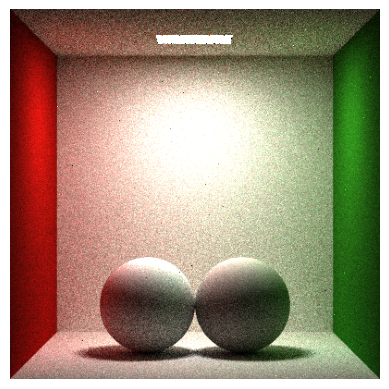

In [48]:
image_np = image.to_numpy()
# if np.isnan(image_np).any() or np.isinf(image_np).any():
#     print("Warning: NaN or Inf values detected in the image")
# image_np = np.clip(image_np, 0, 1)  # Clip values between 0 and 1
plt.imshow(image_np)
plt.axis('off')
plt.show()

/var/folders/wh/k56cqfld3sb6mcx2fr_1w3rm0000gn/T/ipykernel_15742/3787219574.py:3: RuntimeWarning: invalid value encountered in power
  ldr_image = np.power(ldr_image, 1.0 / gamma)
/Users/dipanjan/LightTransportSimulator/lib/python3.11/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


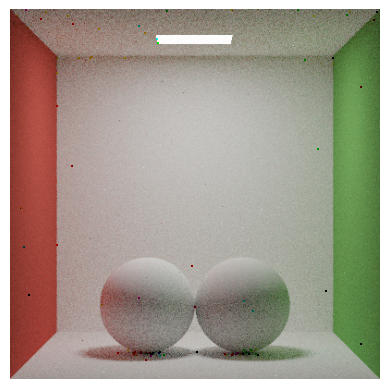

In [49]:
def tone_mapping(hdr_image, gamma=2.2):
    ldr_image = hdr_image / (1.0 + hdr_image)
    ldr_image = np.power(ldr_image, 1.0 / gamma)
    return np.clip(ldr_image, 0, 1)

ldr_image = tone_mapping(image_np)

# Display the tone-mapped image
plt.imshow(ldr_image)
plt.axis('off')
plt.show()

/var/folders/wh/k56cqfld3sb6mcx2fr_1w3rm0000gn/T/ipykernel_15742/3787219574.py:3: RuntimeWarning: invalid value encountered in power
  ldr_image = np.power(ldr_image, 1.0 / gamma)


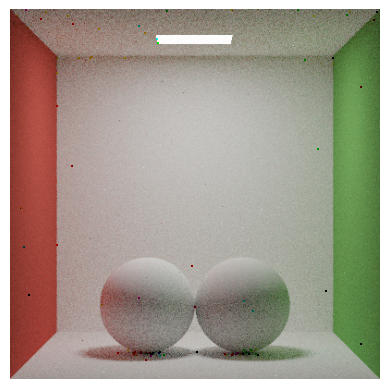

In [50]:
def tone_mapping(hdr_image, gamma=2.2):
    ldr_image = hdr_image / (1.0 + hdr_image)
    ldr_image = np.power(ldr_image, 1.0 / gamma)
    return np.clip(ldr_image, 0, 1)

ldr_image = tone_mapping(image_np)

# Display the tone-mapped image
plt.imshow(ldr_image)
plt.axis('off')
plt.show()